---

# 작물 질병 감지 모델링 프로세스 (PyTorch)

---

1단계: 환경 설정

- PyTorch, torchvision, timm, torchmetrics 설치
- GPU 사용 가능 여부 확인 (CUDA)

---

2단계: 데이터 탐색 (EDA)

- 클래스 목록 및 분포 확인 (작물 종류 × 건강/질병)
- 클래스 불균형 여부 파악
- 샘플 이미지 시각화
- 이미지 크기, 포맷 확인

---

3단계: 데이터 전처리 및 준비

- Train / Validation / Test 분리 (예: 70 / 15 / 15)
- `ImageFolder` 또는 Custom `Dataset` 클래스 구성
- **Data Augmentation 정의 (Train용)**
  - 회전, 뒤집기, 색상 변환, RandomCrop 등
- Normalize (ImageNet 평균/표준편차 사용 — Transfer Learning 기준)
- `DataLoader` 구성 (batch size, shuffle, num_workers)

---

4단계: 모델 구성

| 모델 | 설명 | 목적 |
|------|------|------|
| **DNN (MLP)** | 이미지를 1D로 펼쳐 입력 | 성능 비교 기준선 |
| **직접 구현 CNN** | 3~5개 Conv Layer 구성 | 성능 하한선 파악 |
| **Transfer Learning** | EfficientNet-B0 또는 ResNet50 (timm) | 성능 극대화 |

> Transfer Learning 시 마지막 분류 레이어를 클래스 수에 맞게 교체

---

5단계: 학습

- **Loss Function**: `CrossEntropyLoss`
- **Optimizer**: `Adam` 또는 `AdamW`
- **LR Scheduler**: `CosineAnnealingLR` 또는 `ReduceLROnPlateau`
- **Early Stopping** 적용
- 클래스 불균형 시 → `WeightedRandomSampler` 또는 class weight 적용

---

6단계: 평가

- Accuracy, Precision, Recall, **F1-score**
- Confusion Matrix 시각화
- 모델별 성능 비교표 작성

---

7단계: 분석 및 해석

- 오분류 샘플 시각화
- **Grad-CAM**: 모델이 어느 부위를 보고 판단했는지 시각화
- 최종 모델 선택 근거 정리

---

전체 흐름

```
데이터 탐색 (EDA)
    ↓
전처리 / 증강 / DataLoader 구성
    ↓
DNN 학습 → CNN 학습 → Transfer Learning 학습
    ↓
성능 비교 (Accuracy, F1, Confusion Matrix)
    ↓
최종 모델 선정 → Grad-CAM 해석
```

---


## 1단계: 환경 설정

In [1]:
import importlib
import sys

# 확인할 라이브러리 목록
libraries = {
    "torch": "PyTorch",
    "torchvision": "torchvision",
    "timm": "timm",
    "torchmetrics": "torchmetrics",
}

print("=" * 50)
print("라이브러리 설치 여부 확인")
print("=" * 50)

all_installed = True

for module_name, display_name in libraries.items():
    spec = importlib.util.find_spec(module_name)
    if spec is not None:
        module = importlib.import_module(module_name)
        version = getattr(module, "__version__", "버전 정보 없음")
        print(f"[O] {display_name:<15} 설치됨  (v{version})")
    else:
        print(f"[X] {display_name:<15} 미설치")
        all_installed = False

print("=" * 50)

# GPU (CUDA) 확인
try:
    import torch
    cuda_available = torch.cuda.is_available()
    print(f"\nGPU (CUDA) 사용 가능 여부: {'가능' if cuda_available else '불가능 (CPU 사용)'}")
    if cuda_available:
        print(f"  - CUDA 버전     : {torch.version.cuda}")
        print(f"  - GPU 이름      : {torch.cuda.get_device_name(0)}")
        print(f"  - GPU 개수      : {torch.cuda.device_count()}")
except Exception as e:
    print(f"\nGPU 확인 중 오류 발생: {e}")

print("=" * 50)

# 미설치 라이브러리 안내
if not all_installed:
    print("\n아래 명령어로 미설치 라이브러리를 설치하세요:")
    print("  pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118")
    print("  pip install timm torchmetrics")
else:
    print("\n모든 라이브러리가 설치되어 있습니다.")

print(f"\nPython 버전: {sys.version}")


라이브러리 설치 여부 확인
[O] PyTorch         설치됨  (v2.6.0+cu124)
[O] torchvision     설치됨  (v0.21.0+cu124)
[X] timm            미설치
[X] torchmetrics    미설치

GPU (CUDA) 사용 가능 여부: 가능
  - CUDA 버전     : 12.4
  - GPU 이름      : NVIDIA GeForce RTX 4060 Laptop GPU
  - GPU 개수      : 1

아래 명령어로 미설치 라이브러리를 설치하세요:
  pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118
  pip install timm torchmetrics

Python 버전: 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:36:00) [MSC v.1944 64 bit (AMD64)]


In [2]:
# timm, torchmetrics 설치
!pip install timm torchmetrics


  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.6 MB 2.8 MB/s eta 0:00:01
   -------------------- ------------------- 1.3/2.6 MB 3.5 MB/s eta 0:00:01
   ---------------------------- ----------- 1.8/2.6 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 2.6/2.6 MB 3.6 MB/s  0:00:00
   ---------------------------------------- 0.0/983.4 kB ? eta -:--:--
   --------------------- ------------------ 524.3/983.4 kB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 983.4/983.4 kB 3.6 MB/s  0:00:00
   ---------------------------------------- 0.0/625.2 kB ? eta -:--:--
   ---------------------------------------- 625.2/625.2 kB 3.3 MB/s  0:00:00
   -

In [3]:
import importlib

libraries = {
    "torch": "PyTorch",
    "torchvision": "torchvision",
    "timm": "timm",
    "torchmetrics": "torchmetrics",
}

print("=" * 50)
print("라이브러리 설치 여부 확인")
print("=" * 50)

for module_name, display_name in libraries.items():
    spec = importlib.util.find_spec(module_name)
    if spec is not None:
        module = importlib.import_module(module_name)
        version = getattr(module, "__version__", "버전 정보 없음")
        print(f"[O] {display_name:<15} 설치됨  (v{version})")
    else:
        print(f"[X] {display_name:<15} 미설치")

print("=" * 50)

라이브러리 설치 여부 확인
[O] PyTorch         설치됨  (v2.6.0+cu124)
[O] torchvision     설치됨  (v0.21.0+cu124)


c:\Users\Admin\miniconda3\envs\yolo-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[O] timm            설치됨  (v1.0.26)
[O] torchmetrics    설치됨  (v1.9.0)


## 2단계: 데이터 탐색 (EDA)

In [5]:
import os
from pathlib import Path
import pandas as pd

DATA_DIR = Path("C:/Users/Admin/hipython/object/dataset")

class_folders = sorted([f for f in DATA_DIR.iterdir() if f.is_dir()])

records = []
for folder in class_folders:
    parts = folder.name.split("__")
    crop = parts[0]
    condition = parts[1] if len(parts) > 1 else "unknown"
    label = "healthy" if "healthy" in condition.lower() else "disease"
    count = len(list(folder.glob("*.*")))
    records.append({"crop": crop, "condition": condition, "label": label, "count": count})

df = pd.DataFrame(records)

# 작물별 클래스 구성 확인
print("=== 작물별 클래스 구성 ===\n")
for crop, group in df.groupby("crop"):
    labels = group["label"].tolist()
    has_disease = "disease" in labels
    has_healthy = "healthy" in labels
    status = "✔ 포함" if has_disease else "✘ healthy만 존재 → 제외 대상"
    print(f"{crop:<25} | 클래스 수: {len(group)} | {status}")

# 제외 대상 작물 목록
exclude_crops = df.groupby("crop").filter(lambda x: "disease" not in x["label"].values)["crop"].unique()
print(f"\n제외 대상 작물: {list(exclude_crops)}")

# 제외 후 데이터 현황
df_filtered = df[~df["crop"].isin(exclude_crops)]
print(f"\n제외 후 클래스 수: {len(df_filtered)}")
print(f"제외 후 전체 이미지 수: {df_filtered['count'].sum():,}장")


=== 작물별 클래스 구성 ===

Apple                     | 클래스 수: 4 | ✔ 포함
Cherry                    | 클래스 수: 2 | ✔ 포함
Corn                      | 클래스 수: 4 | ✔ 포함
Grape                     | 클래스 수: 4 | ✔ 포함
Peach                     | 클래스 수: 2 | ✔ 포함
Pepper,_bell              | 클래스 수: 2 | ✔ 포함
Potato                    | 클래스 수: 3 | ✔ 포함
Strawberry                | 클래스 수: 2 | ✔ 포함
Tomato                    | 클래스 수: 10 | ✔ 포함

제외 대상 작물: []

제외 후 클래스 수: 33
제외 후 전체 이미지 수: 40,000장


In [ ]:
#데이터 경로 설정 및 클래스 목록 확인

import os
from pathlib import Path

# 데이터 경로 설정
DATA_DIR = Path("C:/Users/Admin/Downloads/dataset")

# 클래스 폴더 목록
class_folders = sorted([f for f in DATA_DIR.iterdir() if f.is_dir()])

print(f"전체 클래스 수: {len(class_folders)}\n")
print(f"{'클래스명':<50} {'이미지 수':>8}")
print("-" * 60)

total = 0
for folder in class_folders:
    count = len(list(folder.glob("*.*")))
    total += count
    print(f"{folder.name:<50} {count:>8}장")

print("-" * 60)
print(f"{'전체 합계':<50} {total:>8}장")


전체 클래스 수: 33

클래스명                                                  이미지 수
------------------------------------------------------------
Apple___Apple_scab                                      630장
Apple___Black_rot                                       621장
Apple___Cedar_apple_rust                                275장
Apple___healthy                                        1645장
Cherry___healthy                                        854장
Cherry___Powdery_mildew                                1052장
Corn___Cercospora_leaf_spot Gray_leaf_spot              513장
Corn___Common_rust                                     1192장
Corn___healthy                                         1162장
Corn___Northern_Leaf_Blight                             985장
Grape___Black_rot                                      1180장
Grape___Esca_(Black_Measles)                           1383장
Grape___healthy                                         423장
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)             1076장
Peach___Bac

In [ ]:
# 작물 종류별/건강, 질병 분포 분석

import pandas as pd

records = []

for folder in class_folders:
    name = folder.name
    parts = name.split("__")
    crop = parts[0]
    condition = parts[1] if len(parts) > 1 else "unknown"
    label = "healthy" if "healthy" in condition.lower() else "disease"
    count = len(list(folder.glob("*.*")))
    records.append({"crop": crop, "condition": condition, "label": label, "count": count})

df = pd.DataFrame(records)

print("=== 작물 종류별 이미지 수 ===")
print(df.groupby("crop")["count"].sum().sort_values(ascending=False).to_string())

print("\n=== 건강 / 질병 전체 분포 ===")
summary = df.groupby("label")["count"].sum()
print(summary)
print(f"\n질병 비율: {summary['disease'] / summary.sum() * 100:.1f}%")
print(f"건강 비율: {summary['healthy'] / summary.sum() * 100:.1f}%")


=== 작물 종류별 이미지 수 ===
crop
Tomato          18160
Grape            4062
Corn             3852
Apple            3171
Peach            2657
Pepper,_bell     2475
Potato           2152
Cherry           1906
Strawberry       1565

=== 건강 / 질병 전체 분포 ===
label
disease    31879
healthy     8121
Name: count, dtype: int64

질병 비율: 79.7%
건강 비율: 20.3%


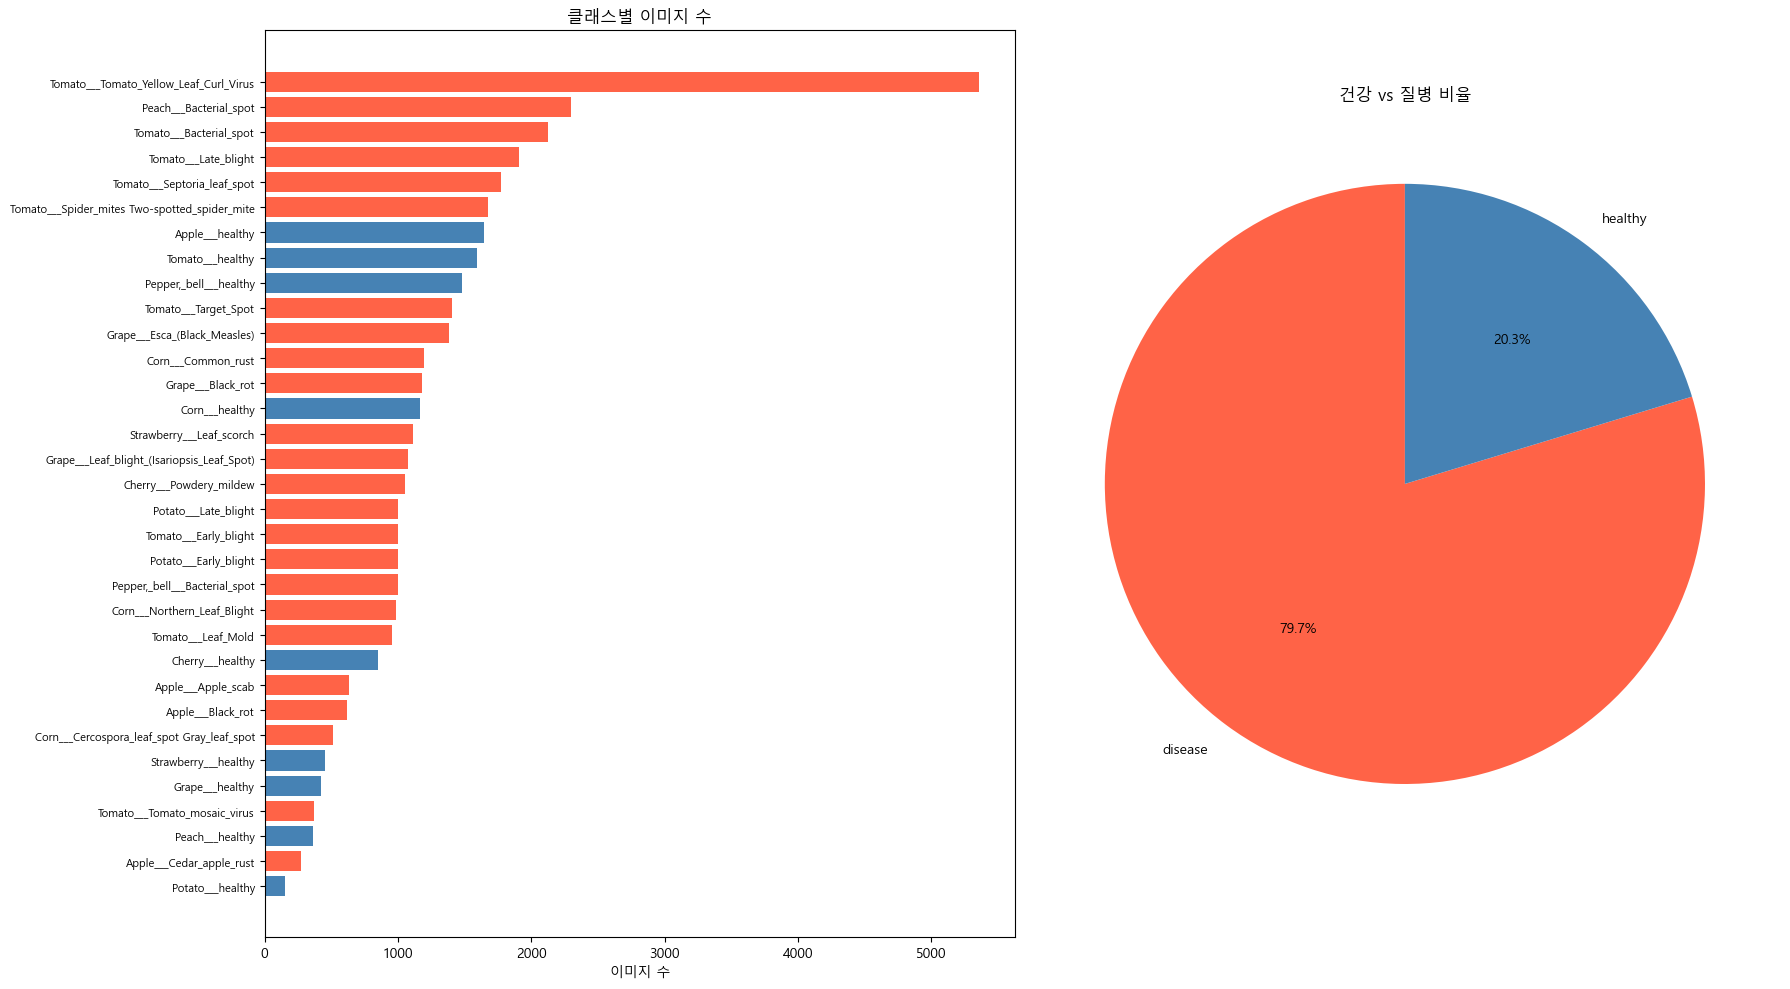

In [11]:
# 클래스 분포 시각화

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# 클래스 전체 이름(crop__condition)으로 표시
df["class_name"] = df["crop"] + "__" + df["condition"]
df_sorted = df.sort_values("count", ascending=True)

axes[0].barh(df_sorted["class_name"], df_sorted["count"],
             color=df_sorted["label"].map({"healthy": "steelblue", "disease": "tomato"}))
axes[0].set_title("클래스별 이미지 수")
axes[0].set_xlabel("이미지 수")
axes[0].tick_params(axis='y', labelsize=8)

summary = df.groupby("label")["count"].sum()
axes[1].pie(summary, labels=summary.index, autopct="%1.1f%%",
            colors=["tomato", "steelblue"], startangle=90)
axes[1].set_title("건강 vs 질병 비율")

plt.tight_layout()
plt.show()


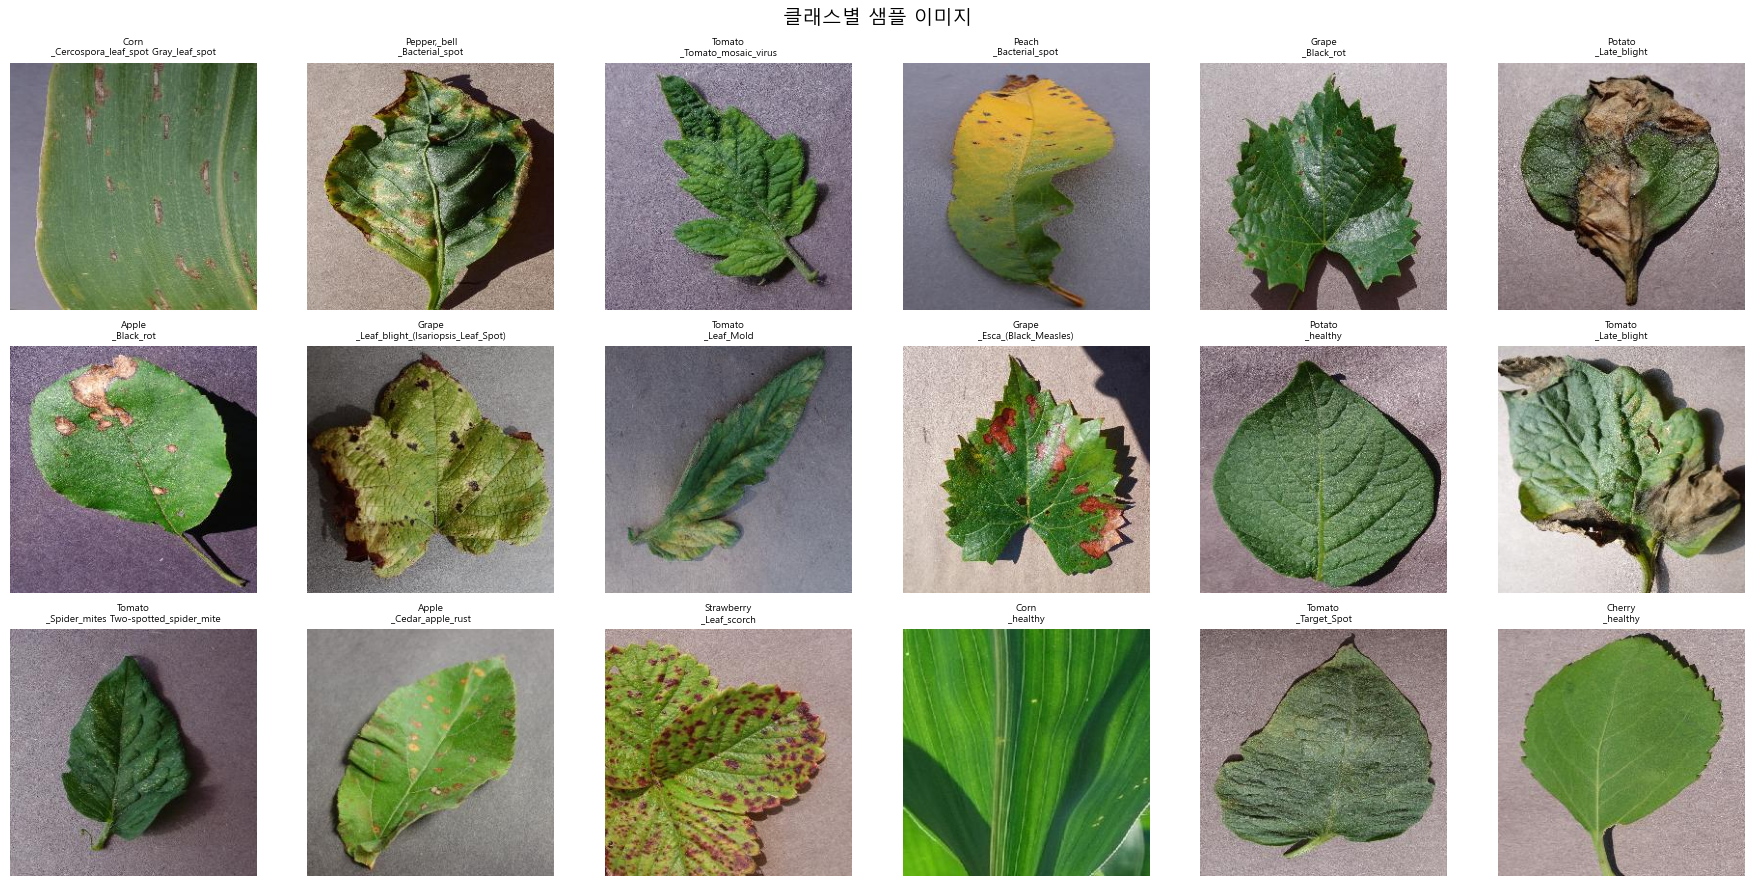

In [ ]:
# 샘플 이미지 시각화

import random
from PIL import Image

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
axes = axes.flatten()

sampled = random.sample(class_folders, min(18, len(class_folders)))

for i, folder in enumerate(sampled):
    images = list(folder.glob("*.*"))
    if images:
        img = Image.open(random.choice(images))
        axes[i].imshow(img)
        axes[i].set_title(folder.name.replace("__", "\n"), fontsize=7)
        axes[i].axis("off")

plt.suptitle("클래스별 샘플 이미지", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# 이미지 크기 분포 확인

from collections import Counter

sizes = []
for folder in class_folders:
    for img_path in list(folder.glob("*.*"))[:10]:  # 클래스당 10장 샘플링
        try:
            with Image.open(img_path) as img:
                sizes.append(img.size)  # (width, height)
        except:
            pass

size_counter = Counter(sizes)
print("=== 이미지 크기 분포 (상위 10개) ===")
for size, cnt in size_counter.most_common(10):
    print(f"  {size[0]}x{size[1]} : {cnt}개")


=== 이미지 크기 분포 (상위 10개) ===
  256x256 : 330개


### 2단계 데이터 탐색 시각화 Summary

## [5] 결과 분석

모든 이미지가 **256×256으로 통일**되어 있습니다.

| 항목 | 내용 |
|------|------|
| 이미지 크기 | **256 × 256** 단일 크기 |
| 별도 리사이즈 필요 여부 | **불필요** |

---

## EDA 종합 정리

| 항목 | 내용 | 비고 |
|------|------|------|
| 전체 이미지 수 | 40,000장 | |
| 클래스 수 | 33개 | 9개 작물 |
| 이미지 크기 | 256×256 | 통일되어 있음 |
| 클래스 불균형 | 최소 152장 vs 최대 5,357장 | WeightedRandomSampler 필요 |
| 건강/질병 비율 | 20.3% vs 79.7% | class weight 적용 필요 |
| 주요 소수 클래스 | Potato__healthy (152장) | Augmentation 강화 필요 |

---


## 3단계: 데이터 전처리 및 준비

In [12]:
# Train/Validation/Test 분리

import os
import shutil
import random
from pathlib import Path

DATA_DIR = Path("C:/Users/Admin/Downloads/dataset")
OUTPUT_DIR = Path("C:/Users/Admin/Downloads/dataset_split")

random.seed(42)

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

for class_folder in DATA_DIR.iterdir():
    if not class_folder.is_dir():
        continue

    images = list(class_folder.glob("*.*"))
    random.shuffle(images)

    n = len(images)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)

    splits = {
        "train": images[:n_train],
        "val":   images[n_train:n_train + n_val],
        "test":  images[n_train + n_val:]
    }

    for split_name, split_images in splits.items():
        dest_dir = OUTPUT_DIR / split_name / class_folder.name
        dest_dir.mkdir(parents=True, exist_ok=True)
        for img in split_images:
            shutil.copy(img, dest_dir / img.name)

print("데이터 분리 완료!")

# 분리 결과 확인
for split in ["train", "val", "test"]:
    total = sum(len(list((OUTPUT_DIR / split / c).glob("*.*")))
                for c in os.listdir(OUTPUT_DIR / split))
    print(f"  {split:<6}: {total:,}장")


데이터 분리 완료!
  train : 27,986장
  val   : 5,985장
  test  : 6,029장


In [13]:
# Transform 및 DataLoader 구성

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

# ImageNet 기준 정규화 값 (Transfer Learning 사용 시 표준)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# Transform 정의
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),          # EfficientNet/ResNet 입력 크기
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# Dataset 구성
train_dataset = datasets.ImageFolder(OUTPUT_DIR / "train", transform=train_transform)
val_dataset   = datasets.ImageFolder(OUTPUT_DIR / "val",   transform=val_test_transform)
test_dataset  = datasets.ImageFolder(OUTPUT_DIR / "test",  transform=val_test_transform)

print(f"Train: {len(train_dataset):,}장 | Val: {len(val_dataset):,}장 | Test: {len(test_dataset):,}장")
print(f"클래스 수: {len(train_dataset.classes)}")


Train: 27,986장 | Val: 5,985장 | Test: 6,029장
클래스 수: 33


In [14]:
# WeightedRandomSampler 구성 (클래스 불균형 대응)

# 클래스별 가중치 계산
targets = torch.tensor(train_dataset.targets)
class_counts = torch.bincount(targets)
class_weights = 1.0 / class_counts.float()
sample_weights = class_weights[targets]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# DataLoader 구성
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=4, pin_memory=True)

print("DataLoader 구성 완료!")
print(f"Train 배치 수: {len(train_loader)}")
print(f"Val   배치 수: {len(val_loader)}")
print(f"Test  배치 수: {len(test_loader)}")


DataLoader 구성 완료!
Train 배치 수: 875
Val   배치 수: 188
Test  배치 수: 189


In [15]:
# 정상 동작 확인

images, labels = next(iter(train_loader))
print(f"배치 이미지 shape : {images.shape}")   # [32, 3, 224, 224]
print(f"배치 레이블 shape : {labels.shape}")   # [32]
print(f"픽셀값 범위       : {images.min():.2f} ~ {images.max():.2f}")


배치 이미지 shape : torch.Size([32, 3, 224, 224])
배치 레이블 shape : torch.Size([32])
픽셀값 범위       : -2.12 ~ 2.64


## 4단계: 모델 구성

In [16]:
# DNN (MLP)

import torch.nn as nn

class DNN(nn.Module):
    def __init__(self, num_classes=33):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 224 * 224, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)


In [17]:
# CNN (직접 구현)

class CNN(nn.Module):
    def __init__(self, num_classes=33):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),  # 112x112
            nn.Dropout2d(0.25),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),  # 56x56
            nn.Dropout2d(0.25),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),  # 28x28
            nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


In [18]:
# Transfer Learning (EfficientNet-B0)

import timm

def build_efficientnet(num_classes=33, pretrained=True):
    model = timm.create_model("efficientnet_b0", pretrained=pretrained)
    model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    return model


## 5단계: 학습

In [19]:
# 공통 학습 함수

import torch
from torchmetrics import Accuracy, F1Score
import time

def train_model(model, train_loader, val_loader, model_name,
                num_epochs=20, lr=1e-3, patience=5):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    acc_metric = Accuracy(task="multiclass", num_classes=33).to(device)
    f1_metric  = F1Score(task="multiclass", num_classes=33, average="macro").to(device)

    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}
    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(num_epochs):
        start = time.time()

        # --- Train ---
        model.train()
        train_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        # --- Validation ---
        model.eval()
        val_loss = 0.0
        acc_metric.reset(); f1_metric.reset()

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()
                acc_metric.update(outputs, labels)
                f1_metric.update(outputs, labels)

        val_loss /= len(val_loader)
        val_acc = acc_metric.compute().item()
        val_f1  = f1_metric.compute().item()

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        elapsed = time.time() - start
        print(f"[{model_name}] Epoch {epoch+1:02d}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f} | "
              f"Time: {elapsed:.1f}s")

        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f"best_{model_name}.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early Stopping at Epoch {epoch+1}")
                break

    return history


In [20]:
# 모델별 학습 실행

# DNN
dnn_model = DNN(num_classes=33)
dnn_history = train_model(dnn_model, train_loader, val_loader,
                           model_name="DNN", num_epochs=20, lr=1e-3)

# CNN
cnn_model = CNN(num_classes=33)
cnn_history = train_model(cnn_model, train_loader, val_loader,
                           model_name="CNN", num_epochs=20, lr=1e-3)

# EfficientNet
eff_model = build_efficientnet(num_classes=33, pretrained=True)
eff_history = train_model(eff_model, train_loader, val_loader,
                           model_name="EfficientNet", num_epochs=20, lr=1e-4)


[DNN] Epoch 01/20 | Train Loss: 2.3636 | Val Loss: 1.5896 | Val Acc: 0.5216 | Val F1: 0.4521 | Time: 175.5s
[DNN] Epoch 02/20 | Train Loss: 1.7546 | Val Loss: 1.3186 | Val Acc: 0.5794 | Val F1: 0.5202 | Time: 122.8s
[DNN] Epoch 03/20 | Train Loss: 1.5704 | Val Loss: 1.1360 | Val Acc: 0.6449 | Val F1: 0.5928 | Time: 77.0s
[DNN] Epoch 04/20 | Train Loss: 1.4650 | Val Loss: 1.0795 | Val Acc: 0.6543 | Val F1: 0.6076 | Time: 77.3s
[DNN] Epoch 05/20 | Train Loss: 1.3756 | Val Loss: 1.0090 | Val Acc: 0.6814 | Val F1: 0.6339 | Time: 100.1s
[DNN] Epoch 06/20 | Train Loss: 1.3299 | Val Loss: 0.9503 | Val Acc: 0.7029 | Val F1: 0.6577 | Time: 119.9s
[DNN] Epoch 07/20 | Train Loss: 1.2817 | Val Loss: 0.9227 | Val Acc: 0.7054 | Val F1: 0.6627 | Time: 130.6s
[DNN] Epoch 08/20 | Train Loss: 1.2309 | Val Loss: 0.9304 | Val Acc: 0.7056 | Val F1: 0.6779 | Time: 83.4s
[DNN] Epoch 09/20 | Train Loss: 1.1697 | Val Loss: 0.8193 | Val Acc: 0.7368 | Val F1: 0.7065 | Time: 77.5s
[DNN] Epoch 10/20 | Train Loss: 

c:\Users\Admin\miniconda3\envs\yolo-env\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Admin\.cache\huggingface\hub\models--timm--efficientnet_b0.ra_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


[EfficientNet] Epoch 01/20 | Train Loss: 0.4813 | Val Loss: 0.0528 | Val Acc: 0.9850 | Val F1: 0.9846 | Time: 157.5s
[EfficientNet] Epoch 02/20 | Train Loss: 0.0551 | Val Loss: 0.0378 | Val Acc: 0.9888 | Val F1: 0.9892 | Time: 126.0s
[EfficientNet] Epoch 03/20 | Train Loss: 0.0370 | Val Loss: 0.0363 | Val Acc: 0.9895 | Val F1: 0.9906 | Time: 122.6s
[EfficientNet] Epoch 04/20 | Train Loss: 0.0297 | Val Loss: 0.0214 | Val Acc: 0.9937 | Val F1: 0.9933 | Time: 123.3s
[EfficientNet] Epoch 05/20 | Train Loss: 0.0173 | Val Loss: 0.0233 | Val Acc: 0.9931 | Val F1: 0.9926 | Time: 122.6s
[EfficientNet] Epoch 06/20 | Train Loss: 0.0169 | Val Loss: 0.0171 | Val Acc: 0.9947 | Val F1: 0.9948 | Time: 123.0s
[EfficientNet] Epoch 07/20 | Train Loss: 0.0143 | Val Loss: 0.0167 | Val Acc: 0.9953 | Val F1: 0.9953 | Time: 121.8s
[EfficientNet] Epoch 08/20 | Train Loss: 0.0114 | Val Loss: 0.0178 | Val Acc: 0.9953 | Val F1: 0.9944 | Time: 121.6s
[EfficientNet] Epoch 09/20 | Train Loss: 0.0096 | Val Loss: 0.01

## 6단계: 평가

In [22]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [24]:
import matplotlib.pyplot as plt
from torchmetrics import ConfusionMatrix
import seaborn as sns

def evaluate_model(model, test_loader, model_name, class_names):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.load_state_dict(torch.load(f"best_{model_name}.pth"))
    model = model.to(device)
    model.eval()

    acc_metric = Accuracy(task="multiclass", num_classes=33).to(device)
    f1_metric  = F1Score(task="multiclass", num_classes=33, average="macro").to(device)
    cm_metric  = ConfusionMatrix(task="multiclass", num_classes=33).to(device)

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            acc_metric.update(outputs, labels)
            f1_metric.update(outputs, labels)
            cm_metric.update(outputs, labels)

    acc = acc_metric.compute().item()
    f1  = f1_metric.compute().item()
    cm  = cm_metric.compute().cpu().numpy()

    print(f"\n{'='*50}")
    print(f"[{model_name}] 최종 테스트 결과")
    print(f"  Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  F1 Score : {f1:.4f}")
    print(f"{'='*50}")

    # Confusion Matrix 시각화
    plt.figure(figsize=(16, 14))
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=90, fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()
    plt.show()

    return {"model": model_name, "accuracy": acc, "f1": f1}


# 학습 곡선 비교 시각화
def plot_history(histories, names):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for history, name in zip(histories, names):
        axes[0].plot(history["val_loss"], label=name)
        axes[1].plot(history["val_f1"],  label=name)
    axes[0].set_title("Validation Loss"); axes[0].legend()
    axes[1].set_title("Validation F1 Score"); axes[1].legend()
    plt.tight_layout()
    plt.show()



[DNN] 최종 테스트 결과
  Accuracy : 0.7897 (78.97%)
  F1 Score : 0.7651


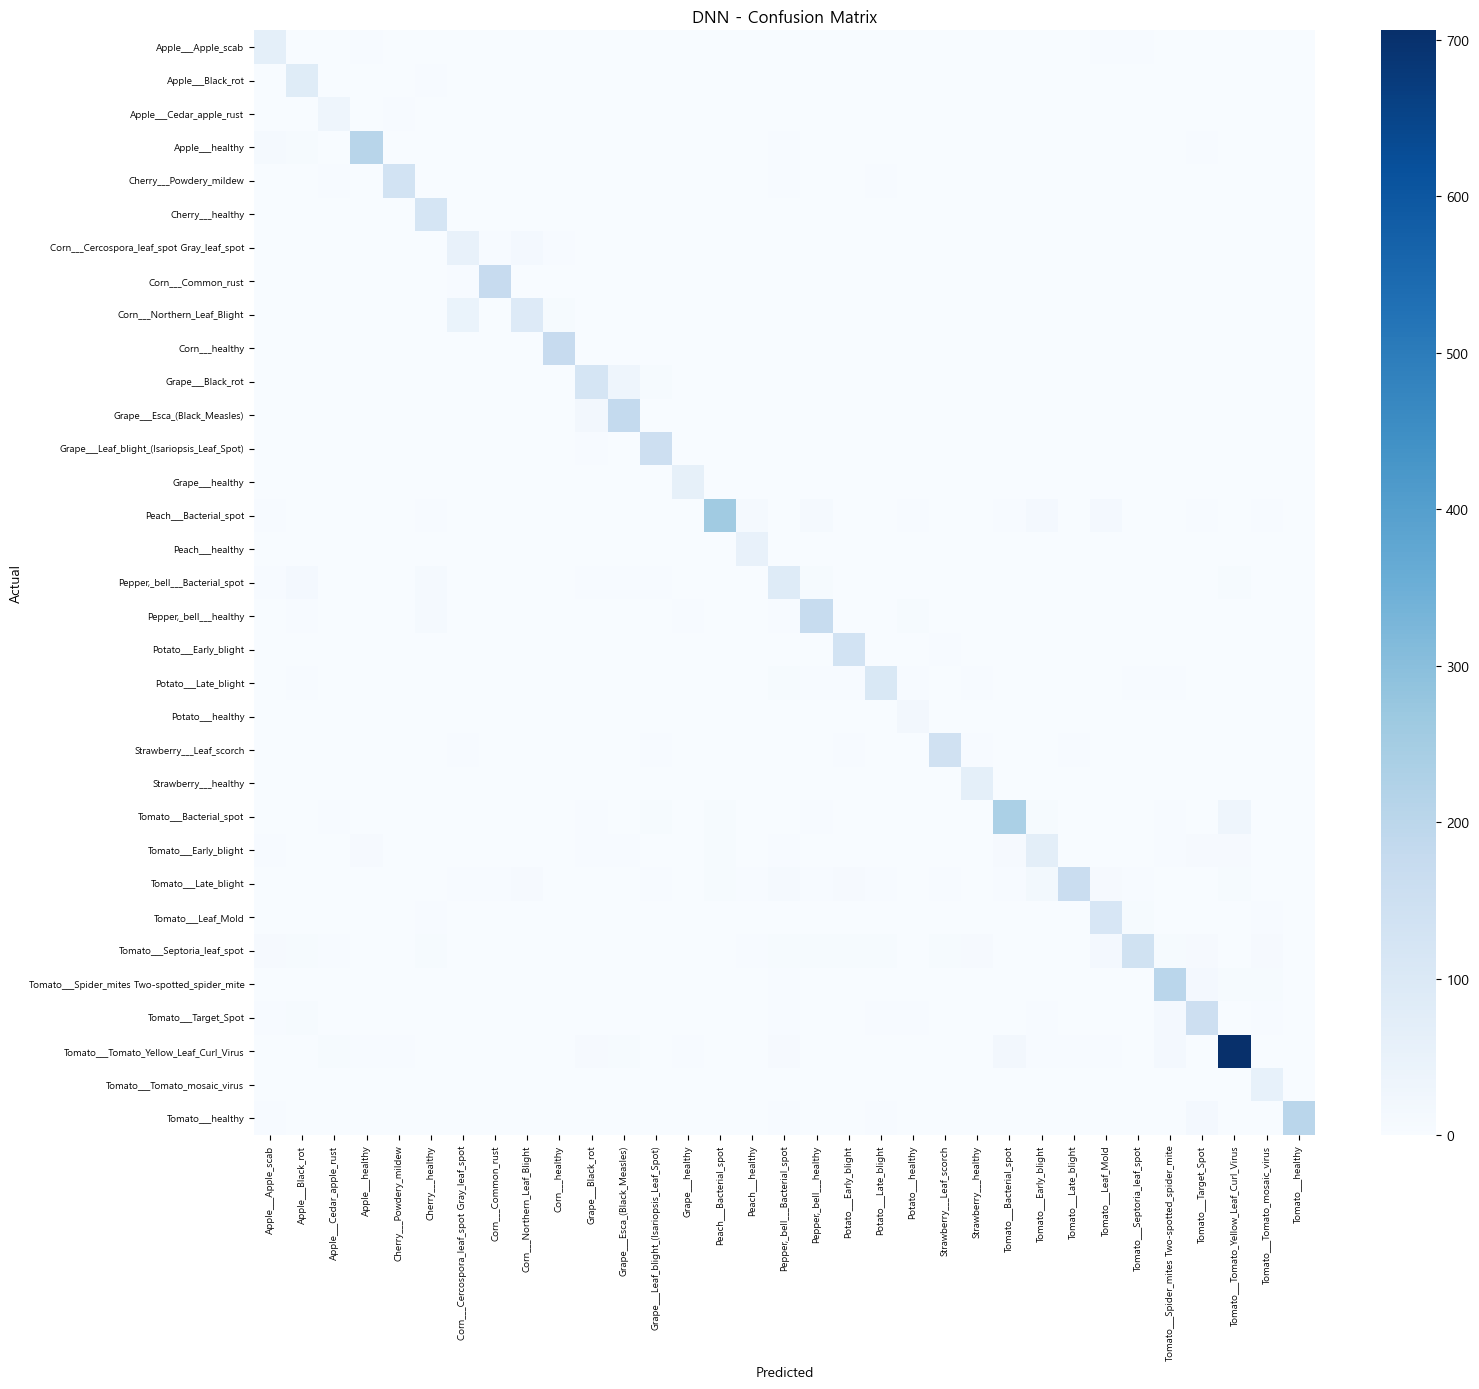


[CNN] 최종 테스트 결과
  Accuracy : 0.8701 (87.01%)
  F1 Score : 0.8509


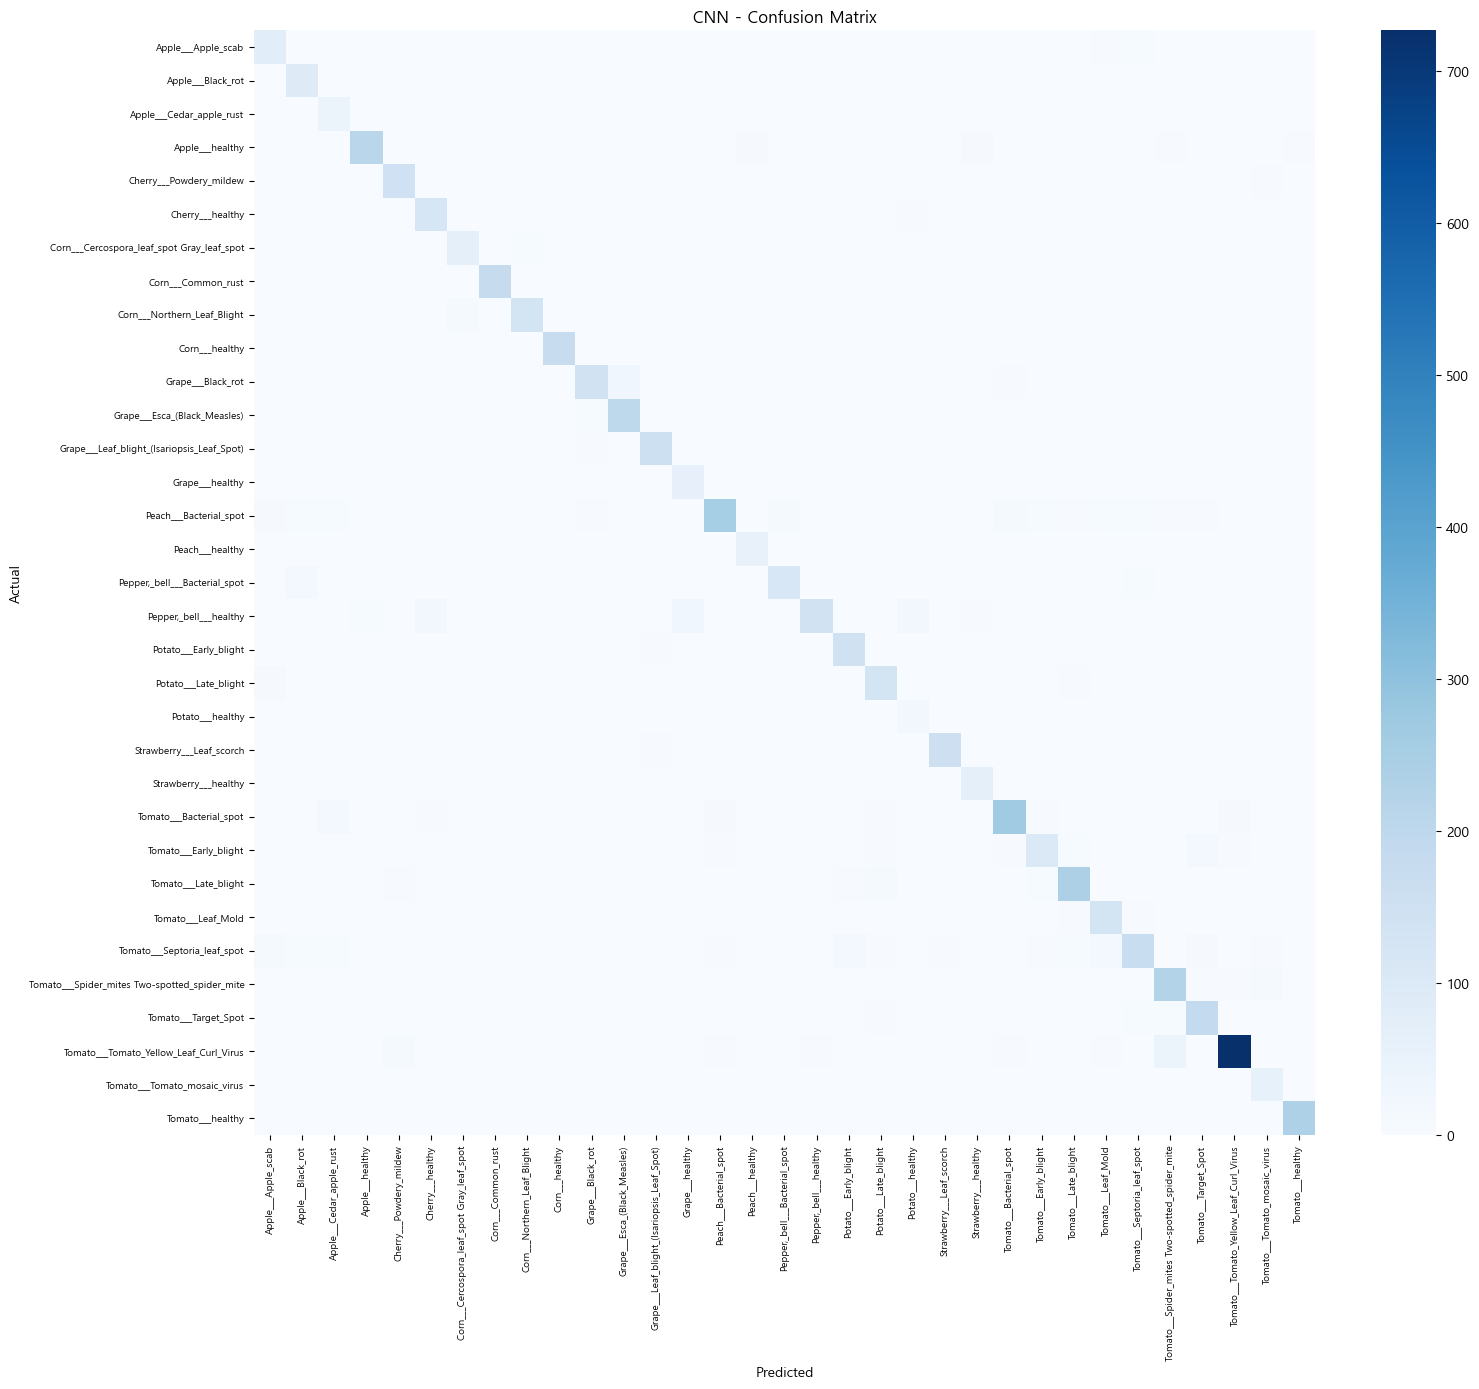


[EfficientNet] 최종 테스트 결과
  Accuracy : 0.9965 (99.65%)
  F1 Score : 0.9956


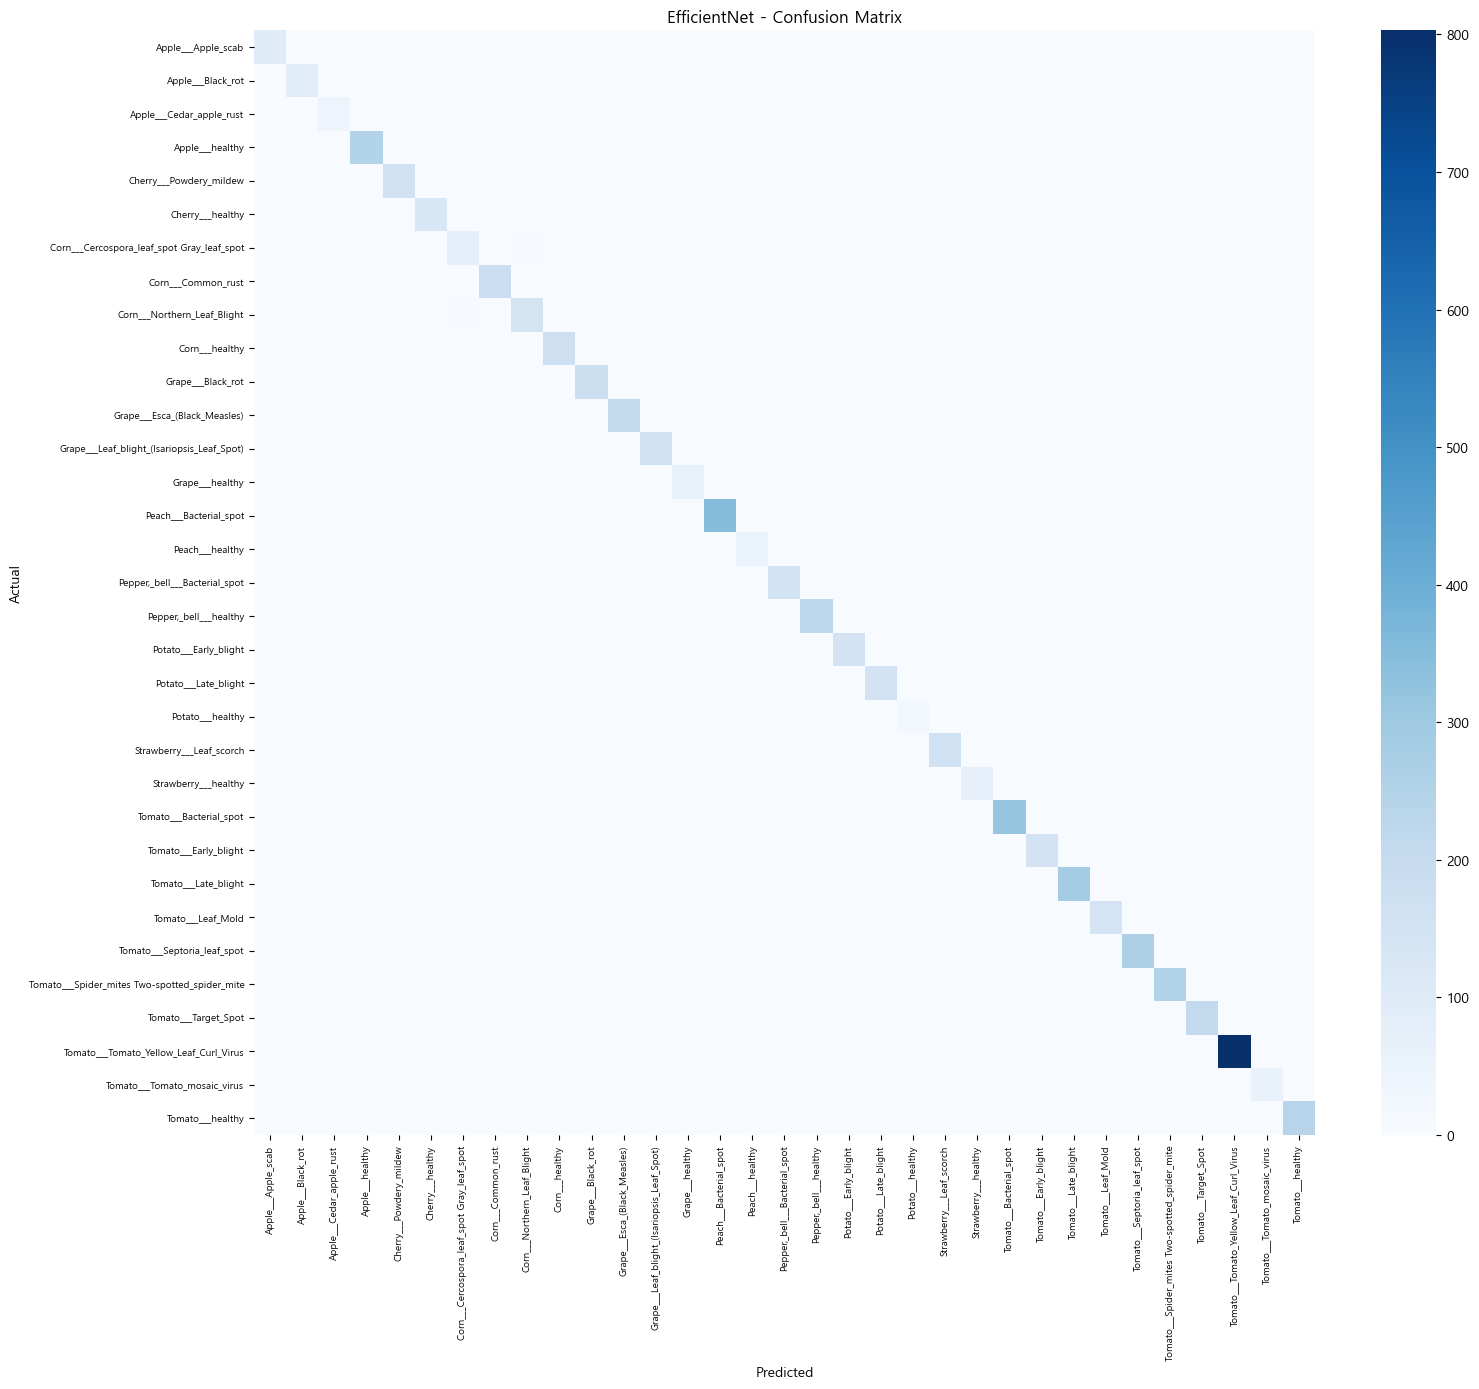


=== 모델 성능 비교 ===
       model  accuracy       f1
         DNN  0.789683 0.765085
         CNN  0.870128 0.850869
EfficientNet  0.996517 0.995643


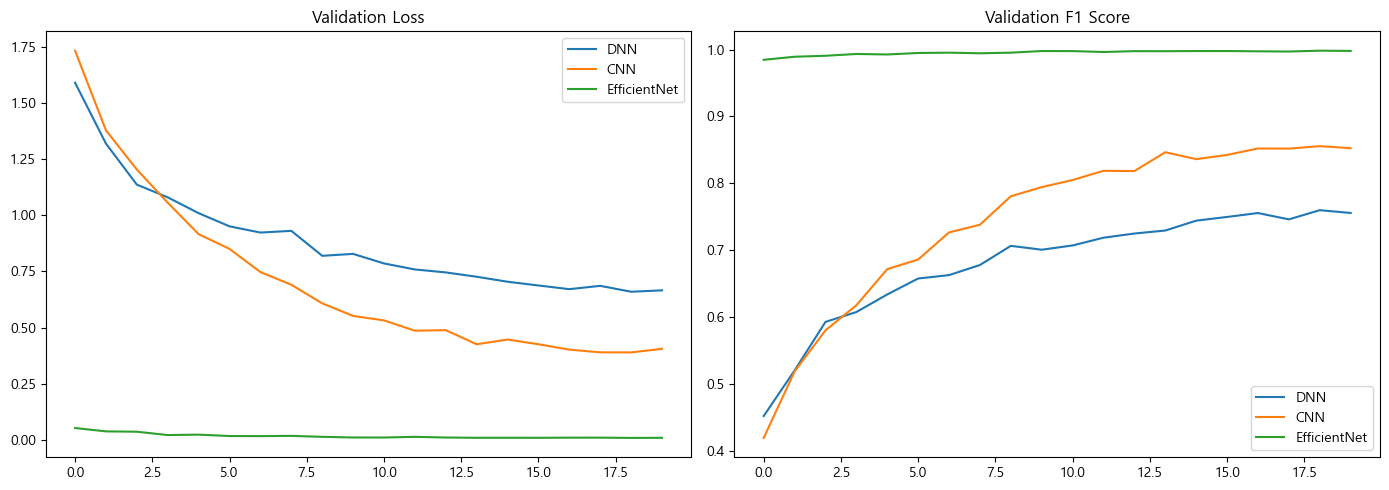

In [25]:
# 평가 실행

class_names = train_dataset.classes

results = []
for model, name in [(dnn_model, "DNN"),
                    (cnn_model, "CNN"),
                    (eff_model, "EfficientNet")]:
    result = evaluate_model(model, test_loader, name, class_names)
    results.append(result)

# 모델 성능 비교표
import pandas as pd
df_results = pd.DataFrame(results)
print("\n=== 모델 성능 비교 ===")
print(df_results.to_string(index=False))

# 학습 곡선 비교
plot_history([dnn_history, cnn_history, eff_history],
             ["DNN", "CNN", "EfficientNet"])



[이미지 1] 최종 예측: Pepper,_bell___healthy  (52.24%)  🟢 건강

[이미지 2] 최종 예측: Pepper,_bell___healthy  (60.81%)  🟢 건강


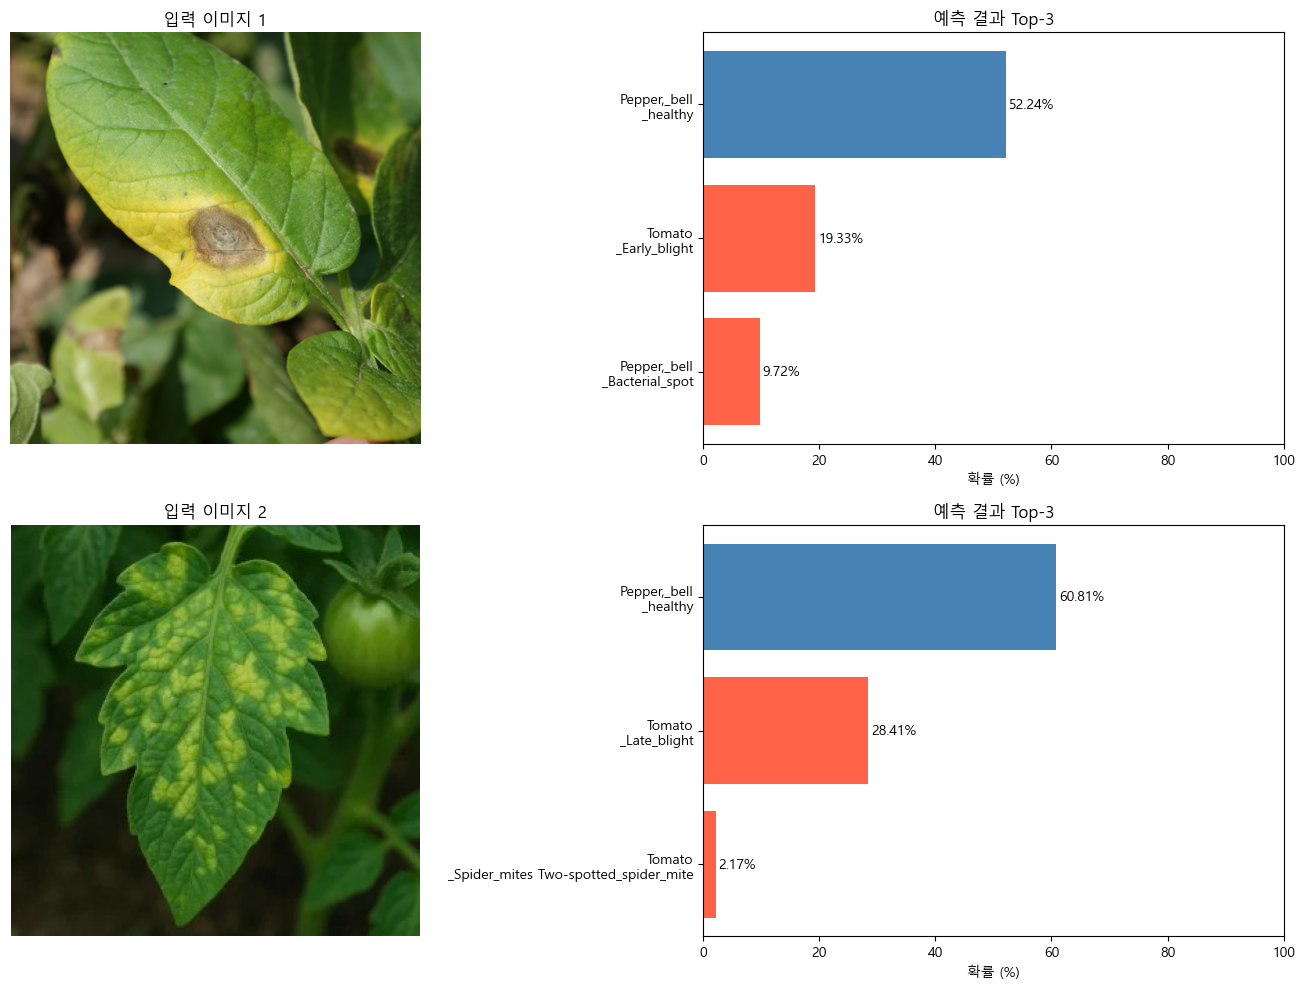

In [26]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 설정 ──────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 이미지 경로 설정 (저장된 경로로 수정해 주세요)
IMAGE_PATHS = [
    "C:/Users/Admin/hipython/object/ca2020_early_blight_potato_damage1.png",  # 첫 번째 이미지
    "C:/Users/Admin/hipython/object/tomato_mosaic_virus.jpg",  # 두 번째 이미지
]

# ── 모델 로드 ──────────────────────────────────────
eff_model = build_efficientnet(num_classes=33, pretrained=False)
eff_model.load_state_dict(torch.load("best_EfficientNet.pth", map_location=device))
eff_model = eff_model.to(device)
eff_model.eval()

# ── 전처리 ─────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ── 추론 함수 ──────────────────────────────────────
def predict(image_path, model, class_names, top_k=3):
    img = Image.open(image_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = F.softmax(output, dim=1)[0]

    top_probs, top_indices = torch.topk(probs, top_k)
    results = [(class_names[i], p.item()) for i, p in zip(top_indices, top_probs)]
    return img, results

# ── 시각화 ─────────────────────────────────────────
class_names = train_dataset.classes

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, image_path in enumerate(IMAGE_PATHS):
    img, results = predict(image_path, eff_model, class_names, top_k=3)

    # 이미지 출력
    axes[idx][0].imshow(img)
    axes[idx][0].axis("off")
    axes[idx][0].set_title(f"입력 이미지 {idx+1}", fontsize=12)

    # 예측 결과 출력
    labels = [r[0].replace("__", "\n") for r in results]
    probs  = [r[1] * 100 for r in results]
    colors = ["tomato" if "healthy" not in r[0] else "steelblue" for r in results]

    bars = axes[idx][1].barh(labels, probs, color=colors)
    axes[idx][1].set_xlim(0, 100)
    axes[idx][1].set_xlabel("확률 (%)")
    axes[idx][1].set_title(f"예측 결과 Top-3", fontsize=12)
    axes[idx][1].invert_yaxis()

    for bar, prob in zip(bars, probs):
        axes[idx][1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                          f"{prob:.2f}%", va="center", fontsize=10)

    # 최종 예측 출력
    top_class, top_prob = results[0]
    label_kor = "🔴 질병" if "healthy" not in top_class else "🟢 건강"
    print(f"\n[이미지 {idx+1}] 최종 예측: {top_class}  ({top_prob*100:.2f}%)  {label_kor}")

plt.tight_layout()
plt.show()



[이미지 1] 최종 예측: Tomato___Early_blight  (92.86%)  🔴 질병

[이미지 2] 최종 예측: Tomato___Tomato_mosaic_virus  (99.87%)  🔴 질병


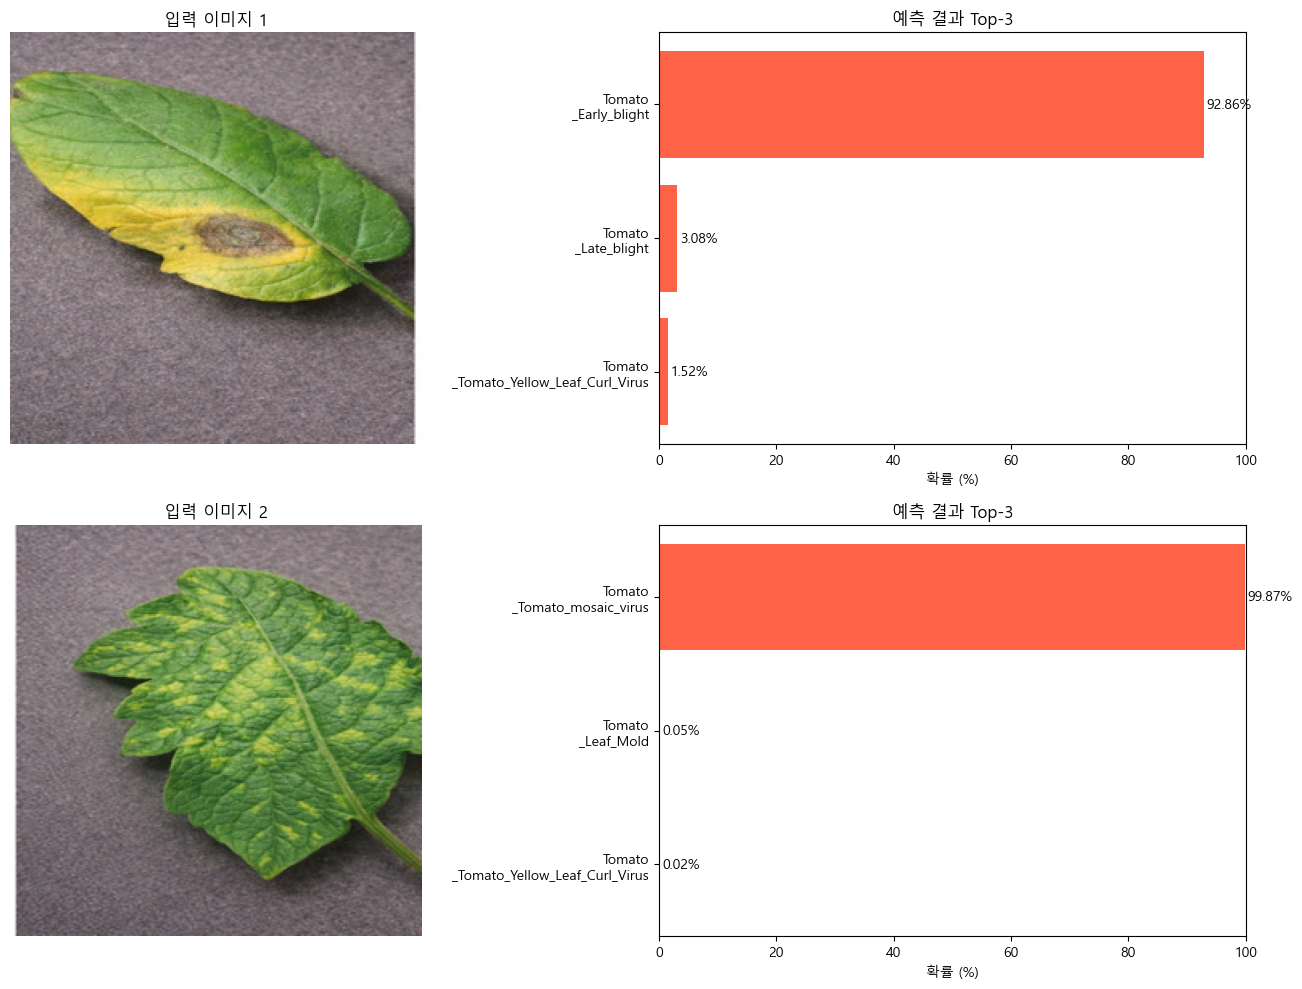

In [27]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 설정 ──────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 이미지 경로 설정 (저장된 경로로 수정해 주세요)
IMAGE_PATHS = [
    "C:/Users/Admin/hipython/object/1..png",  # 첫 번째 이미지
    "C:/Users/Admin/hipython/object/2..png",  # 두 번째 이미지
]

# ── 모델 로드 ──────────────────────────────────────
eff_model = build_efficientnet(num_classes=33, pretrained=False)
eff_model.load_state_dict(torch.load("best_EfficientNet.pth", map_location=device))
eff_model = eff_model.to(device)
eff_model.eval()

# ── 전처리 ─────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ── 추론 함수 ──────────────────────────────────────
def predict(image_path, model, class_names, top_k=3):
    img = Image.open(image_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = F.softmax(output, dim=1)[0]

    top_probs, top_indices = torch.topk(probs, top_k)
    results = [(class_names[i], p.item()) for i, p in zip(top_indices, top_probs)]
    return img, results

# ── 시각화 ─────────────────────────────────────────
class_names = train_dataset.classes

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, image_path in enumerate(IMAGE_PATHS):
    img, results = predict(image_path, eff_model, class_names, top_k=3)

    # 이미지 출력
    axes[idx][0].imshow(img)
    axes[idx][0].axis("off")
    axes[idx][0].set_title(f"입력 이미지 {idx+1}", fontsize=12)

    # 예측 결과 출력
    labels = [r[0].replace("__", "\n") for r in results]
    probs  = [r[1] * 100 for r in results]
    colors = ["tomato" if "healthy" not in r[0] else "steelblue" for r in results]

    bars = axes[idx][1].barh(labels, probs, color=colors)
    axes[idx][1].set_xlim(0, 100)
    axes[idx][1].set_xlabel("확률 (%)")
    axes[idx][1].set_title(f"예측 결과 Top-3", fontsize=12)
    axes[idx][1].invert_yaxis()

    for bar, prob in zip(bars, probs):
        axes[idx][1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                          f"{prob:.2f}%", va="center", fontsize=10)

    # 최종 예측 출력
    top_class, top_prob = results[0]
    label_kor = "🔴 질병" if "healthy" not in top_class else "🟢 건강"
    print(f"\n[이미지 {idx+1}] 최종 예측: {top_class}  ({top_prob*100:.2f}%)  {label_kor}")

plt.tight_layout()
plt.show()
